In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sklearn

print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [2]:
import os
import random
import time
import copy
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    mean_absolute_error
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", device)

Random seed: 42
Device: cuda


# **Load Dataset** 

In [3]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv


In [8]:
train_path = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv"
test_path = "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(10000, 785)
(60000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **Prepare Dataset**

In [9]:
X_all = train_df.iloc[:, 1:].values.astype(np.float32) / 255.0
y_all = train_df.iloc[:, 0].values.astype(np.int64)

X_test = test_df.iloc[:, 1:].values.astype(np.float32) / 255.0
y_test = test_df.iloc[:, 0].values.astype(np.int64)

print("Training features:", X_all.shape)
print("Test features:", X_test.shape)

Training features: (10000, 784)
Test features: (60000, 784)


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 8000
Validation samples: 2000
Test samples: 60000


# **Class Distribution**

In [11]:
def print_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} distribution")
    for cls, count in zip(unique, counts):
        print(f"Class {cls}: {count}")

print_distribution("Training", y_train)
print_distribution("Validation", y_val)
print_distribution("Test", y_test)


Training distribution
Class 0: 800
Class 1: 800
Class 2: 800
Class 3: 800
Class 4: 800
Class 5: 800
Class 6: 800
Class 7: 800
Class 8: 800
Class 9: 800

Validation distribution
Class 0: 200
Class 1: 200
Class 2: 200
Class 3: 200
Class 4: 200
Class 5: 200
Class 6: 200
Class 7: 200
Class 8: 200
Class 9: 200

Test distribution
Class 0: 6000
Class 1: 6000
Class 2: 6000
Class 3: 6000
Class 4: 6000
Class 5: 6000
Class 6: 6000
Class 7: 6000
Class 8: 6000
Class 9: 6000


In [13]:
distribution_df = pd.DataFrame({
    "Class": range(10),
    "Train": [np.sum(y_train == i) for i in range(10)],
    "Validation": [np.sum(y_val == i) for i in range(10)],
    "Test": [np.sum(y_test == i) for i in range(10)]
})

distribution_df

,Class,Train,Validation,Test
0,0,800,200,6000
1,1,800,200,6000
2,2,800,200,6000
3,3,800,200,6000
4,4,800,200,6000
5,5,800,200,6000
6,6,800,200,6000
7,7,800,200,6000
8,8,800,200,6000
9,9,800,200,6000


# **PART 1 — BACKPROPAGATION FROM SCRATCH**

In [14]:
rng = np.random.default_rng(SEED)

indices = rng.choice(len(X_train), size=5000, replace=False)

X_np_train = X_train[indices]
y_np_train = y_train[indices]

print(X_np_train.shape)

(5000, 784)


# Helper Functions

In [16]:
#helper functions
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(np.float32)


def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cross_entropy(y_true, probabilities):
    n = len(y_true)

    return -np.mean(
        np.log(probabilities[np.arange(n), y_true] + 1e-12)
    )

# Initialize weights

In [17]:
#initialize weights
np.random.seed(SEED)

W1 = np.random.randn(784, 64).astype(np.float32) * 0.01
b1 = np.zeros((1, 64), dtype=np.float32)

W2 = np.random.randn(64, 10).astype(np.float32) * 0.01
b2 = np.zeros((1, 10), dtype=np.float32)

# Forward pass

In [18]:
# forward pass
def forward_pass(X, W1, b1, W2, b2):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    probabilities = softmax(Z2)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "probabilities": probabilities
    }

    return probabilities, cache

# Backward Pass

In [19]:
# backward pass
def backward_pass(y, cache, W2):

    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    probabilities = cache["probabilities"]

    batch_size = X.shape[0]

    dZ2 = probabilities.copy()
    dZ2[np.arange(batch_size), y] -= 1
    dZ2 /= batch_size

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Gradient Descent Update

In [20]:
#gradient decent update
def update_parameters(
    W1, b1, W2, b2,
    dW1, db1, dW2, db2,
    learning_rate
):

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    return W1, b1, W2, b2

# Training for 20 epochs

In [21]:
# train for 20 epochs
epochs = 20
batch_size = 128
learning_rate = 0.1

part1_losses = []

for epoch in range(epochs):

    permutation = np.random.permutation(len(X_np_train))

    X_shuffled = X_np_train[permutation]
    y_shuffled = y_np_train[permutation]

    epoch_losses = []

    for start in range(0, len(X_shuffled), batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        probabilities, cache = forward_pass(
            X_batch,
            W1,
            b1,
            W2,
            b2
        )

        loss = cross_entropy(
            y_batch,
            probabilities
        )

        dW1, db1, dW2, db2 = backward_pass(
            y_batch,
            cache,
            W2
        )

        W1, b1, W2, b2 = update_parameters(
            W1,
            b1,
            W2,
            b2,
            dW1,
            db1,
            dW2,
            db2,
            learning_rate
        )

        epoch_losses.append(loss)

    average_loss = np.mean(epoch_losses)

    part1_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )

Epoch 01/20 - Loss: 2.1346
Epoch 02/20 - Loss: 1.3766
Epoch 03/20 - Loss: 1.0299
Epoch 04/20 - Loss: 0.8763
Epoch 05/20 - Loss: 0.7868
Epoch 06/20 - Loss: 0.7467
Epoch 07/20 - Loss: 0.7036
Epoch 08/20 - Loss: 0.6868
Epoch 09/20 - Loss: 0.6214
Epoch 10/20 - Loss: 0.6329
Epoch 11/20 - Loss: 0.5830
Epoch 12/20 - Loss: 0.5976
Epoch 13/20 - Loss: 0.5481
Epoch 14/20 - Loss: 0.5459
Epoch 15/20 - Loss: 0.5196
Epoch 16/20 - Loss: 0.5035
Epoch 17/20 - Loss: 0.5354
Epoch 18/20 - Loss: 0.4974
Epoch 19/20 - Loss: 0.4701
Epoch 20/20 - Loss: 0.4755


# Plot for training loss

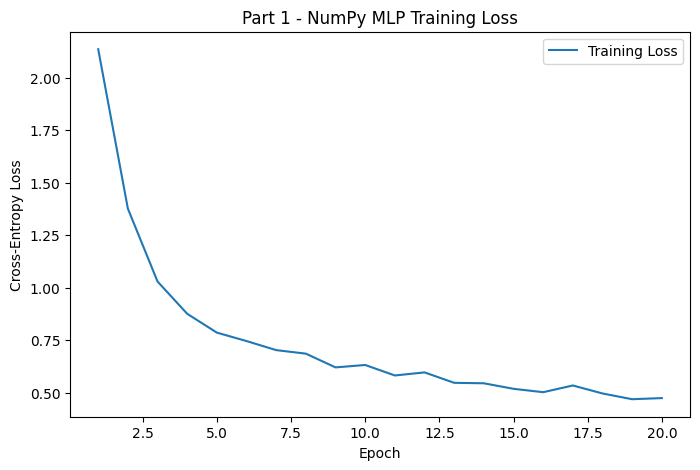

In [22]:
# plot training loss
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    part1_losses,
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Part 1 - NumPy MLP Training Loss")
plt.legend()

plt.show()

In [25]:
X_check = X_np_train[:64]
y_check = y_np_train[:64]

probabilities, cache = forward_pass(
    X_check,
    W1,
    b1,
    W2,
    b2
)

np_dW1, np_db1, np_dW2, np_db2 = backward_pass(
    y_check,
    cache,
    W2
)

class GradientCheckMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x
torch_model = GradientCheckMLP()

 #transpose
with torch.no_grad():

    torch_model.fc1.weight.copy_(
        torch.tensor(W1.T)
    )

    torch_model.fc1.bias.copy_(
        torch.tensor(b1.flatten())
    )

    torch_model.fc2.weight.copy_(
        torch.tensor(W2.T)
    )

    torch_model.fc2.bias.copy_(
        torch.tensor(b2.flatten())
    )

# Forward and backward pass in pytorch

In [28]:
# forward+backward pass with py torch
X_check_t = torch.tensor(
    X_check,
    dtype=torch.float32
)

y_check_t = torch.tensor(
    y_check,
    dtype=torch.long
)

criterion = nn.CrossEntropyLoss()

torch_model.zero_grad()

outputs = torch_model(X_check_t)

torch_loss = criterion(
    outputs,
    y_check_t
)

torch_loss.backward()

#compare gradients
torch_dW1 = torch_model.fc1.weight.grad.numpy().T
torch_dW2 = torch_model.fc2.weight.grad.numpy().T

difference_W1 = np.max(
    np.abs(np_dW1 - torch_dW1)
)

difference_W2 = np.max(
    np.abs(np_dW2 - torch_dW2)
)

print(
    "Maximum absolute difference W1:",
    difference_W1
)

print(
    "Maximum absolute difference W2:",
    difference_W2
)


Maximum absolute difference W1: 1.4901161e-08
Maximum absolute difference W2: 1.0430813e-07


# Conclusion
The maximum absolute gradient difference for W1 was 1.4 e-08 and for W2
was 1.04 e-07. Both values are very close to zero, indicating that the
manual NumPy backward pass agrees with PyTorch autograd and is therefore
implemented correctly.


# **PART 2 — BASELINE MODEL & ACTIVATIONS** 

# Dataset Loaders

In [29]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)


# Activation Model

In [30]:
class ActivationMLP(nn.Module):

    def __init__(self, activation="relu"):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        if activation == "sigmoid":
            self.activation = nn.Sigmoid()

        elif activation == "tanh":
            self.activation = nn.Tanh()

        elif activation == "relu":
            self.activation = nn.ReLU()

        elif activation == "leaky_relu":
            self.activation = nn.LeakyReLU(0.01)

    def forward(self, x):

        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x


# Generic Validation Function

In [31]:
def evaluate_model(model, loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            total_loss += loss.item() * X_batch.size(0)

            predicted = torch.argmax(
                output,
                dim=1
            )

            correct += (
                predicted == y_batch
            ).sum().item()

            total += y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy


# Training Models

In [33]:
def train_activation_model(
    activation_name,
    epochs=15,
    learning_rate=0.001
):

    torch.manual_seed(SEED)

    model = ActivationMLP(
        activation_name
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    first_epoch_gradient = None
    final_epoch_gradient = None

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        gradient_values = []

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            loss.backward()

            gradient_values.append(
                model.fc1.weight.grad
                .abs()
                .mean()
                .item()
            )

            optimizer.step()

            running_loss += (
                loss.item()
                * X_batch.size(0)
            )

        epoch_train_loss = (
            running_loss
            / len(train_loader.dataset)
        )

        val_loss, val_accuracy = evaluate_model(
            model,
            val_loader,
            criterion
        )

        train_losses.append(
            epoch_train_loss
        )

        val_losses.append(
            val_loss
        )

        mean_gradient = np.mean(
            gradient_values
        )

        if epoch == 0:
            first_epoch_gradient = mean_gradient

        if epoch == epochs - 1:
            final_epoch_gradient = mean_gradient

        print(
            activation_name,
            f"Epoch {epoch + 1}/{epochs}",
            f"Train Loss: {epoch_train_loss:.4f}",
            f"Val Loss: {val_loss:.4f}",
            f"Val Acc: {val_accuracy:.4f}"
        )

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "first_gradient": first_epoch_gradient,
        "final_gradient": final_epoch_gradient,
        "val_accuracy": val_accuracy
    }
activation_results = {}

for activation in [
    "sigmoid",
    "tanh",
    "relu",
    "leaky_relu"
]:

    print("\n", activation.upper())

    activation_results[activation] = (
        train_activation_model(
            activation
        )
    )



 SIGMOID
sigmoid Epoch 1/15 Train Loss: 1.8467 Val Loss: 1.3012 Val Acc: 0.5785
sigmoid Epoch 2/15 Train Loss: 1.0544 Val Loss: 0.8815 Val Acc: 0.7120
sigmoid Epoch 3/15 Train Loss: 0.7798 Val Loss: 0.7050 Val Acc: 0.7610
sigmoid Epoch 4/15 Train Loss: 0.6384 Val Loss: 0.6118 Val Acc: 0.7825
sigmoid Epoch 5/15 Train Loss: 0.5586 Val Loss: 0.5577 Val Acc: 0.8115
sigmoid Epoch 6/15 Train Loss: 0.5071 Val Loss: 0.5400 Val Acc: 0.8050
sigmoid Epoch 7/15 Train Loss: 0.4719 Val Loss: 0.5036 Val Acc: 0.8275
sigmoid Epoch 8/15 Train Loss: 0.4433 Val Loss: 0.4914 Val Acc: 0.8235
sigmoid Epoch 9/15 Train Loss: 0.4212 Val Loss: 0.4855 Val Acc: 0.8250
sigmoid Epoch 10/15 Train Loss: 0.4032 Val Loss: 0.4778 Val Acc: 0.8350
sigmoid Epoch 11/15 Train Loss: 0.3907 Val Loss: 0.4676 Val Acc: 0.8330
sigmoid Epoch 12/15 Train Loss: 0.3770 Val Loss: 0.4636 Val Acc: 0.8370
sigmoid Epoch 13/15 Train Loss: 0.3613 Val Loss: 0.4581 Val Acc: 0.8370
sigmoid Epoch 14/15 Train Loss: 0.3510 Val Loss: 0.4444 Val Acc

# Plot for validation loss curves

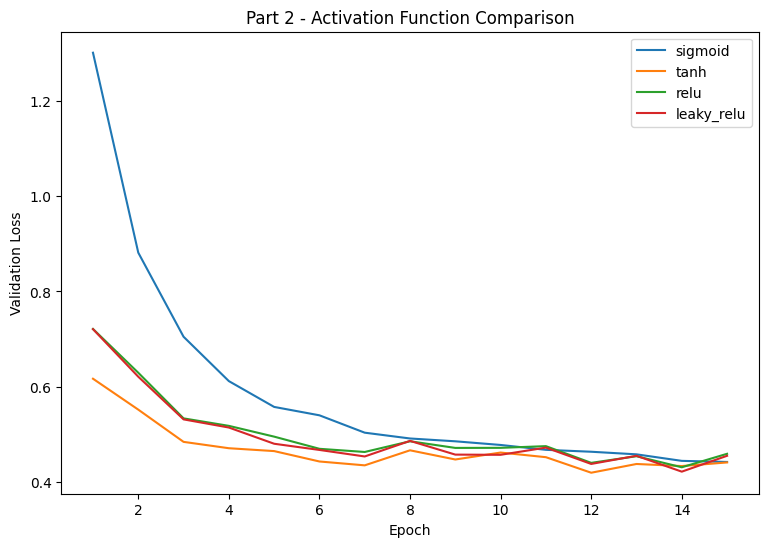

In [34]:
plt.figure(figsize=(9, 6))

for name, result in activation_results.items():

    plt.plot(
        range(
            1,
            len(result["val_losses"]) + 1
        ),
        result["val_losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Part 2 - Activation Function Comparison"
)
plt.legend()

plt.show()


# Gradient Comparison

In [36]:
print("SIGMOID")

print(
    "Epoch 1 gradient:",
    activation_results["sigmoid"]["first_gradient"]
)

print(
    "Final epoch gradient:",
    activation_results["sigmoid"]["final_gradient"]
)

print("\nRELU")

print(
    "Epoch 1 gradient:",
    activation_results["relu"]["first_gradient"]
)

print(
    "Final epoch gradient:",
    activation_results["relu"]["final_gradient"]
)
# dead relu units 
relu_model = activation_results["relu"]["model"]

relu_model.eval()

X_batch, y_batch = next(iter(val_loader))

X_batch = X_batch.to(device)

with torch.no_grad():

    z1 = relu_model.fc1(X_batch)
    activation1 = torch.relu(z1)

dead_units = (
    activation1 == 0
).all(dim=0)

dead_percentage = (
    dead_units.float().mean().item() * 100
)

print(
    f"Dead ReLU units: {dead_percentage:.2f}%"
)


SIGMOID
Epoch 1 gradient: 5.456663729135125e-05
Final epoch gradient: 0.00020841174398175634

RELU
Epoch 1 gradient: 0.0005854261736015952
Final epoch gradient: 0.0007027825927324888
Dead ReLU units: 12.11%


# Conclusion
The sigmoid network produced considerably smaller mean absolute
gradients in the first hidden layer than the ReLU network. This shows
how saturation in sigmoid can reduce the gradient passed through
earlier layers, producing the vanishing-gradient effect.

**Dead ReLU explanation**

Approximately 12.11% of first-layer ReLU units were inactive for every
sample in the selected validation batch. Such units receive zero
activation throughout the batch, illustrating the dead-ReLU problem
when neurons remain permanently on the negative side of the activation.


# **PART 3 — LOSS FUNCTIONS**

# Classification Network

In [38]:
class ClassificationMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


# Cross-entropy training

In [39]:
def train_ce_model(epochs=15):

    torch.manual_seed(SEED)

    model = ClassificationMLP().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item()
                * X_batch.size(0)
            )

        epoch_loss = (
            running_loss /
            len(train_loader.dataset)
        )

        losses.append(epoch_loss)

    return model, losses


# MSE classifier

In [40]:
def train_mse_classifier(epochs=15):

    torch.manual_seed(SEED)

    model = ClassificationMLP().to(device)

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            target_one_hot = torch.nn.functional.one_hot(
                y_batch,
                num_classes=10
            ).float()

            optimizer.zero_grad()

            logits = model(X_batch)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            loss = criterion(
                probabilities,
                target_one_hot
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item()
                * X_batch.size(0)
            )

        epoch_loss = (
            running_loss /
            len(train_loader.dataset)
        )

        losses.append(epoch_loss)

    return model, losses

ce_model, ce_losses = train_ce_model()

mse_model, mse_losses = train_mse_classifier()


# Classification Accuracy Function

In [42]:
def classification_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)

            predictions = output.argmax(dim=1)

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    return correct / total

ce_accuracy = classification_accuracy(
    ce_model,
    val_loader
)

mse_accuracy = classification_accuracy(
    mse_model,
    val_loader
)

print("CE validation accuracy:", ce_accuracy)
print("MSE validation accuracy:", mse_accuracy)


CE validation accuracy: 0.8425
MSE validation accuracy: 0.847


# Plot loss comparison

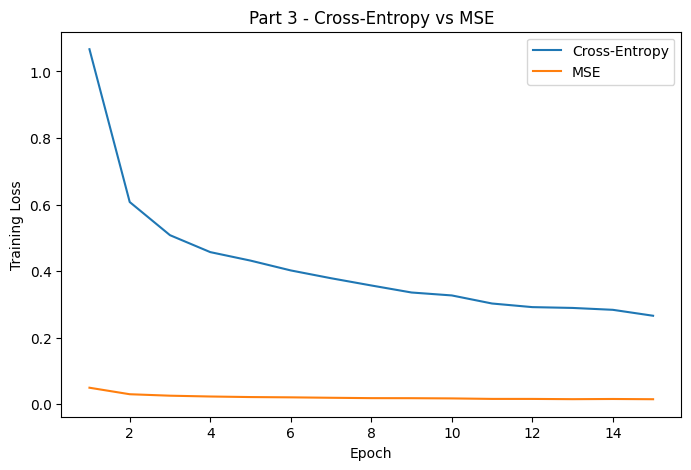

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(ce_losses) + 1),
    ce_losses,
    label="Cross-Entropy"
)

plt.plot(
    range(1, len(mse_losses) + 1),
    mse_losses,
    label="MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(
    "Part 3 - Cross-Entropy vs MSE"
)
plt.legend()

plt.show()


#  Regression Dataset

In [45]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

data = load_diabetes()

X_reg = data.data.astype(np.float32)
y_reg = data.target.astype(np.float32)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=SEED
)

scaler = StandardScaler()

X_reg_train = scaler.fit_transform(
    X_reg_train
).astype(np.float32)

X_reg_test = scaler.transform(
    X_reg_test
).astype(np.float32)
#Regression network:
class RegressionMLP(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)
#Train it:
reg_train_dataset = TensorDataset(
    torch.tensor(X_reg_train),
    torch.tensor(y_reg_train)
)

reg_train_loader = DataLoader(
    reg_train_dataset,
    batch_size=32,
    shuffle=True
)

reg_model = RegressionMLP(
    X_reg_train.shape[1]
).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

for epoch in range(200):

    reg_model.train()

    for X_batch, y_batch in reg_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = reg_model(
            X_batch
        ).squeeze()

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()
        optimizer.step()
#Evaluate:
reg_model.eval()

with torch.no_grad():

    reg_predictions = reg_model(
        torch.tensor(
            X_reg_test,
            dtype=torch.float32
        ).to(device)
    ).squeeze().cpu().numpy()

mse = mean_squared_error(
    y_reg_test,
    reg_predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_reg_test,
    reg_predictions
)

print("Regression MSE :", mse)
print("Regression RMSE:", rmse)
print("Regression MAE :", mae)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Regression MSE : 2883.012939453125
Regression RMSE: 53.693695527995885
Regression MAE : 42.724002838134766


# Conclusion
Cross-entropy is better suited to multi-class classification because it
directly optimizes the likelihood assigned to the correct class.
Combined with softmax, it also provides stronger gradients for
incorrect confident predictions, whereas MSE can produce smaller
gradients and slower convergence.


# **PART 4 — OPTIMIZER COMPARISON**

# Model

In [46]:
class OptimizerMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


# Optimizer factory


In [47]:
def get_optimizer(
    name,
    model,
    learning_rate
):

    if name == "SGD":

        return optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif name == "SGD + Momentum":

        return optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif name == "RMSProp":

        return optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    elif name == "Adam":

        return optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

# Train one optimizer


In [48]:
def train_optimizer_experiment(
    optimizer_name,
    lr,
    epochs=20
):

    torch.manual_seed(SEED)

    model = OptimizerMLP().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = get_optimizer(
        optimizer_name,
        model,
        lr
    )

    train_losses = []

    epoch_85 = None

    start_time = time.perf_counter()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            loss.backward()
            optimizer.step()

            total_loss += (
                loss.item()
                * X_batch.size(0)
            )

        epoch_loss = (
            total_loss /
            len(train_loader.dataset)
        )

        train_losses.append(epoch_loss)

        val_loss, val_acc = evaluate_model(
            model,
            val_loader,
            criterion
        )

        if (
            epoch_85 is None
            and val_acc >= 0.85
        ):
            epoch_85 = epoch + 1

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    final_val_loss, final_val_acc = (
        evaluate_model(
            model,
            val_loader,
            criterion
        )
    )

    return {
        "model": model,
        "losses": train_losses,
        "epoch_85": epoch_85,
        "final_val_acc": final_val_acc,
        "time": elapsed_time,
        "lr": lr
    }


# Experiment A — same learning rate


In [49]:
common_lr = 0.001

optimizer_names = [
    "SGD",
    "SGD + Momentum",
    "RMSProp",
    "Adam"
]

common_lr_results = {}

for name in optimizer_names:

    print(name)

    common_lr_results[name] = (
        train_optimizer_experiment(
            name,
            common_lr
        )
    )


SGD
SGD + Momentum
RMSProp
Adam


# Experiment B — tuned learning rate


In [51]:
tuned_lrs = {
    "SGD": 0.05,
    "SGD + Momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

tuned_results = {}

for name in optimizer_names:

    tuned_results[name] = (
        train_optimizer_experiment(
            name,
            tuned_lrs[name]
        )
    )


# Table


In [52]:
optimizer_table = []

for name in optimizer_names:

    result = tuned_results[name]

    optimizer_table.append({
        "Optimizer": name,
        "Learning rate": result["lr"],
        "Epochs to reach 85% validation accuracy":
            result["epoch_85"],
        "Final validation accuracy":
            result["final_val_acc"],
        "Wall-clock time":
            result["time"]
    })

optimizer_df = pd.DataFrame(
    optimizer_table
)

optimizer_df


,Optimizer,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time
0,SGD,0.050,NaN,0.8050,2.993247
1,SGD + Momentum,0.010,NaN,0.8345,3.162424
2,RMSProp,0.001,12.0,0.8445,3.342507
3,Adam,0.001,18.0,0.8560,3.479778


# Ploting curves


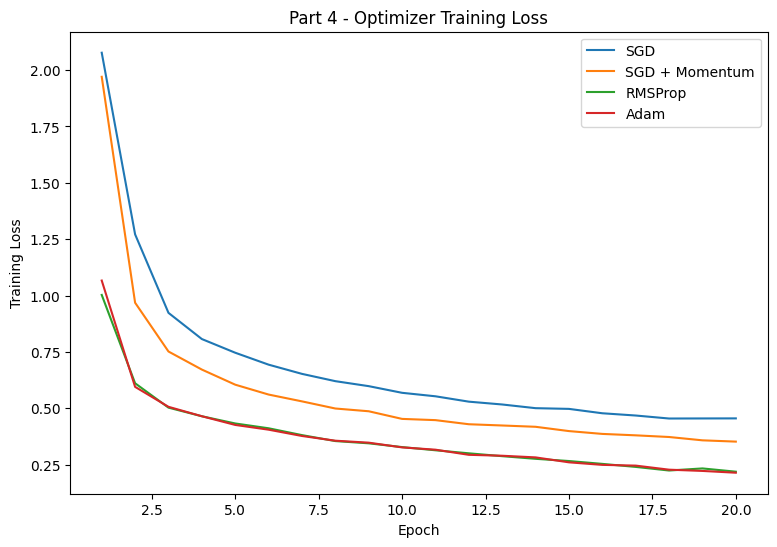

In [53]:
plt.figure(figsize=(9, 6))

for name, result in tuned_results.items():

    plt.plot(
        range(
            1,
            len(result["losses"]) + 1
        ),
        result["losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(
    "Part 4 - Optimizer Training Loss"
)
plt.legend()

plt.show()


# Conclusion
Adam was selected because it reached the target validation accuracy in
fewer epochs while maintaining a high final validation accuracy. It
also required little learning-rate adjustment compared with plain SGD.


# **PART 5 — FORCE OVERFITTING**

# Selecting 2000 samples

In [ ]:
X_small, _, y_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=2000,
    random_state=SEED,
    stratify=y_train
)

small_dataset = TensorDataset(
    torch.tensor(
        X_small,
        dtype=torch.float32
    ),
    torch.tensor(
        y_small,
        dtype=torch.long
    )
)

small_loader = DataLoader(
    small_dataset,
    batch_size=64,
    shuffle=True
)


# Large model



In [55]:
class OverfitMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

# Accuracy + loss


In [56]:
def evaluate_accuracy_loss(
    model,
    loader
):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            running_loss += (
                loss.item()
                * X_batch.size(0)
            )

            prediction = output.argmax(
                dim=1
            )

            correct += (
                prediction == y_batch
            ).sum().item()

            total += len(y_batch)

    return (
        running_loss / total,
        correct / total
    )


# Training until >99%


In [57]:
torch.manual_seed(SEED)

overfit_model = OverfitMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    overfit_model.parameters(),
    lr=0.001
)

train_losses_overfit = []
val_losses_overfit = []

train_acc_history = []
val_acc_history = []

max_epochs = 100

for epoch in range(max_epochs):

    overfit_model.train()

    for X_batch, y_batch in small_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = overfit_model(X_batch)

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()
        optimizer.step()

    train_loss, train_acc = (
        evaluate_accuracy_loss(
            overfit_model,
            small_loader
        )
    )

    val_loss, val_acc = (
        evaluate_accuracy_loss(
            overfit_model,
            val_loader
        )
    )

    train_losses_overfit.append(
        train_loss
    )

    val_losses_overfit.append(
        val_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_acc_history.append(
        val_acc
    )

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc:.4f}, "
        f"Val Acc={val_acc:.4f}"
    )

    if train_acc >= 0.995:
        print(
            "Training accuracy exceeded 99%."
        )
        break


Epoch 1: Train Acc=0.5450, Val Acc=0.5460
Epoch 2: Train Acc=0.6875, Val Acc=0.6780
Epoch 3: Train Acc=0.7640, Val Acc=0.7335
Epoch 4: Train Acc=0.7630, Val Acc=0.7445
Epoch 5: Train Acc=0.8230, Val Acc=0.7800
Epoch 6: Train Acc=0.8390, Val Acc=0.7955
Epoch 7: Train Acc=0.8535, Val Acc=0.7915
Epoch 8: Train Acc=0.8650, Val Acc=0.7995
Epoch 9: Train Acc=0.8570, Val Acc=0.7935
Epoch 10: Train Acc=0.8445, Val Acc=0.7745
Epoch 11: Train Acc=0.8885, Val Acc=0.8135
Epoch 12: Train Acc=0.9000, Val Acc=0.8140
Epoch 13: Train Acc=0.8635, Val Acc=0.7800
Epoch 14: Train Acc=0.8770, Val Acc=0.7950
Epoch 15: Train Acc=0.8885, Val Acc=0.8080
Epoch 16: Train Acc=0.9265, Val Acc=0.8195
Epoch 17: Train Acc=0.8960, Val Acc=0.7885
Epoch 18: Train Acc=0.9000, Val Acc=0.7985
Epoch 19: Train Acc=0.9270, Val Acc=0.8045
Epoch 20: Train Acc=0.9150, Val Acc=0.8045
Epoch 21: Train Acc=0.9375, Val Acc=0.8200
Epoch 22: Train Acc=0.9570, Val Acc=0.8165
Epoch 23: Train Acc=0.9395, Val Acc=0.8070
Epoch 24: Train Acc=

# Identify curve separation


In [58]:
best_val_epoch = int(
    np.argmin(val_losses_overfit)
)

separation_epoch = (
    best_val_epoch + 1
)

print(
    "Estimated separation epoch:",
    separation_epoch
)


Estimated separation epoch: 12


# Plot


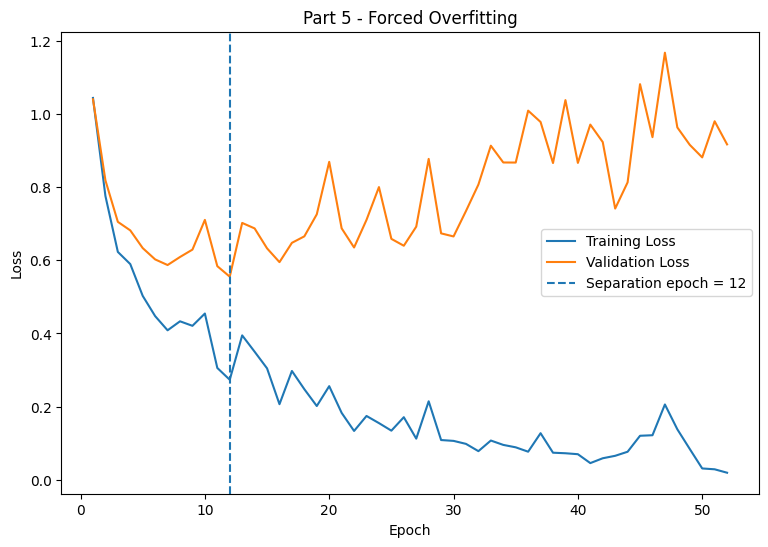

In [59]:
plt.figure(figsize=(9, 6))

epochs_axis = range(
    1,
    len(train_losses_overfit) + 1
)

plt.plot(
    epochs_axis,
    train_losses_overfit,
    label="Training Loss"
)

plt.plot(
    epochs_axis,
    val_losses_overfit,
    label="Validation Loss"
)

plt.axvline(
    separation_epoch,
    linestyle="--",
    label=f"Separation epoch = {separation_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Part 5 - Forced Overfitting"
)
plt.legend()

plt.show()


# Generalization gap


In [60]:
final_train_acc = (
    train_acc_history[-1]
)

final_val_acc = (
    val_acc_history[-1]
)

generalization_gap = (
    final_train_acc
    - final_val_acc
)

print(
    "Training accuracy:",
    final_train_acc
)

print(
    "Validation accuracy:",
    final_val_acc
)

print(
    "Generalization gap:",
    generalization_gap
)


Training accuracy: 0.9955
Validation accuracy: 0.822
Generalization gap: 0.1735000000000001


#  Conclusion
The model exhibits high variance rather than high bias. Its training
accuracy reached 99.5%, while validation accuracy was only 82.2%,
creating a generalization gap of 17.3 percentage points; therefore the
network fits the training data extremely well but does not generalize
equally well.


# **PART 6 — REGULARIZATION**

# General configurable model



In [62]:
class RegularizedMLP(nn.Module):

    def __init__(
        self,
        dropout=0.0,
        batch_norm=False
    ):
        super().__init__()

        layers = []

        input_size = 784

        for _ in range(4):

            layers.append(
                nn.Linear(
                    input_size,
                    512
                )
            )

            if batch_norm:
                layers.append(
                    nn.BatchNorm1d(512)
                )

            layers.append(
                nn.ReLU()
            )

            if dropout > 0:

                layers.append(
                    nn.Dropout(dropout)
                )

            input_size = 512

        layers.append(
            nn.Linear(512, 10)
        )

        self.net = nn.Sequential(
            *layers
        )

    def forward(self, x):
        return self.net(x)

# Generic regularization trainer


In [63]:
def train_regularization_model(
    train_loader_used,
    dropout=0.0,
    batch_norm=False,
    weight_decay=0.0,
    l1_lambda=0.0,
    epochs=40,
    early_stopping=False,
    patience=7
):

    torch.manual_seed(SEED)

    model = RegularizedMLP(
        dropout=dropout,
        batch_norm=batch_norm
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=weight_decay
    )

    best_state = None
    best_val_loss = float("inf")

    patience_counter = 0
    stopping_epoch = None

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader_used:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            if l1_lambda > 0:

                l1_penalty = sum(
                    parameter.abs().sum()
                    for parameter in model.parameters()
                    if parameter.ndim > 1
                )

                loss = (
                    loss
                    + l1_lambda
                    * l1_penalty
                )

            loss.backward()
            optimizer.step()

        train_loss, train_acc = (
            evaluate_accuracy_loss(
                model,
                train_loader_used
            )
        )

        val_loss, val_acc = (
            evaluate_accuracy_loss(
                model,
                val_loader
            )
        )

        if early_stopping:

            if val_loss < best_val_loss:

                best_val_loss = val_loss

                best_state = copy.deepcopy(
                    model.state_dict()
                )

                patience_counter = 0

            else:

                patience_counter += 1

            if patience_counter >= patience:

                stopping_epoch = epoch + 1

                model.load_state_dict(
                    best_state
                )

                break

    train_loss, train_acc = (
        evaluate_accuracy_loss(
            model,
            train_loader_used
        )
    )

    val_loss, val_acc = (
        evaluate_accuracy_loss(
            model,
            val_loader
        )
    )

    return {
        "model": model,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap": train_acc - val_acc,
        "stop_epoch": stopping_epoch
    }


# Part 6A — baseline


In [64]:
baseline_reg = train_regularization_model(
    small_loader
)

print(baseline_reg)


{'model': RegularizedMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=10, bias=True)
  )
), 'train_acc': 0.9775, 'val_acc': 0.8235, 'gap': 0.15400000000000003, 'stop_epoch': None}


# Part 6B — L2 weight decay


In [ ]:
l2_values = [
    1e-5,
    1e-4,
    1e-3,
    1e-2
]

l2_results = {}

for value in l2_values:

    print(
        "L2:",
        value
    )

    l2_results[value] = (
        train_regularization_model(
            small_loader,
            weight_decay=value
        )
    )


# Part 6C — L1


In [68]:
l1_lambda = 1e-6

l1_result = (
    train_regularization_model(
        small_loader,
        l1_lambda=l1_lambda
    )
)

model = l1_result["model"]

all_weights = []

for name, parameter in model.named_parameters():

    if "weight" in name:

        all_weights.append(
            parameter.detach()
            .cpu()
            .flatten()
        )

all_weights = torch.cat(
    all_weights
)

small_weights_percentage = (
    (
        torch.abs(all_weights)
        < 1e-3
    )
    .float()
    .mean()
    .item()
    * 100
)

print(
    f"Weights below 1e-3: "
    f"{small_weights_percentage:.2f}%"
)


Weights below 1e-3: 34.21%


# Part 6D — Dropout


In [69]:
dropout_rates = [
    0.1,
    0.3,
    0.5,
    0.7
]

dropout_results = {}

for rate in dropout_rates:

    print(
        "Dropout:",
        rate
    )

    dropout_results[rate] = (
        train_regularization_model(
            small_loader,
            dropout=rate
        )
    )


Dropout: 0.1
Dropout: 0.3
Dropout: 0.5
Dropout: 0.7


# Part 6E — Batch normalization


In [70]:
batchnorm_result = (
    train_regularization_model(
        small_loader,
        batch_norm=True
    )
)


# Part 6F — Early stopping



In [71]:
PATIENCE = 7

early_stopping_result = (
    train_regularization_model(
        small_loader,
        early_stopping=True,
        patience=PATIENCE,
        epochs=100
    )
)

print(
    "Patience:",
    PATIENCE
)

print(
    "Stopped at epoch:",
    early_stopping_result[
        "stop_epoch"
    ]
)

Patience: 7
Stopped at epoch: 19


# Part 6G — Data augmentation


In [73]:

from torchvision import transforms

augmentation = transforms.Compose([

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    )
])
#Custom dataset:
class AugmentedFashionDataset(
    Dataset
):

    def __init__(
        self,
        X,
        y,
        transform=None
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

        self.transform = transform

    def __len__(self):

        return len(self.y)

    def __getitem__(self, index):

        image = self.X[index].reshape(
            1,
            28,
            28
        )

        if self.transform:

            image = self.transform(
                image
            )

        image = image.flatten()

        return image, self.y[index]
augmented_dataset = (
    AugmentedFashionDataset(
        X_small,
        y_small,
        transform=augmentation
    )
)

augmented_loader = DataLoader(
    augmented_dataset,
    batch_size=64,
    shuffle=True
)

augmentation_result = (
    train_regularization_model(
        augmented_loader
    )
)


# Part 6H — More data


In [82]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch

def create_subset_loader(size):
    # Use a fraction (e.g., 0.5 for 50%) or ensure size <= total samples
    X_subset, _, y_subset, _ = train_test_split(
        X_train,
        y_train,
        train_size=size,
        random_state=SEED,
        stratify=y_train
    )

    dataset = TensorDataset(
        torch.tensor(X_subset, dtype=torch.float32),
        torch.tensor(y_subset, dtype=torch.long)
    )

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=True
    )
    return loader

# Example: Use 50% of the data for loader_10000
loader_10000 = create_subset_loader(0.5)  # 50% of the data

# Example: Use 75% of the data for loader_20000
loader_20000 = create_subset_loader(0.75)  # 75% of the data

more_data_10k = train_regularization_model(loader_10000)
more_data_20k = train_regularization_model(loader_20000)

# Table


In [84]:
regularization_rows = []

regularization_rows.append({
    "Method": "Baseline",
    "Setting": "No regularisation",
    "Train accuracy":
        baseline_reg["train_acc"],
    "Validation accuracy":
        baseline_reg["val_acc"],
    "Gap":
        baseline_reg["gap"]
})

for value, result in l2_results.items():

    regularization_rows.append({
        "Method": "L2 weight decay",
        "Setting": value,
        "Train accuracy":
            result["train_acc"],
        "Validation accuracy":
            result["val_acc"],
        "Gap":
            result["gap"]
    })

regularization_rows.append({
    "Method": "L1 penalty",
    "Setting": l1_lambda,
    "Train accuracy":
        l1_result["train_acc"],
    "Validation accuracy":
        l1_result["val_acc"],
    "Gap":
        l1_result["gap"]
})

for value, result in dropout_results.items():

    regularization_rows.append({
        "Method": "Dropout",
        "Setting": value,
        "Train accuracy":
            result["train_acc"],
        "Validation accuracy":
            result["val_acc"],
        "Gap":
            result["gap"]
    })

regularization_rows.append({
    "Method": "Batch normalisation",
    "Setting": "Enabled",
    "Train accuracy":
        batchnorm_result["train_acc"],
    "Validation accuracy":
        batchnorm_result["val_acc"],
    "Gap":
        batchnorm_result["gap"]
})

regularization_rows.append({
    "Method": "Early stopping",
    "Setting":
        f"Patience={PATIENCE}",
    "Train accuracy":
        early_stopping_result[
            "train_acc"
        ],
    "Validation accuracy":
        early_stopping_result[
            "val_acc"
        ],
    "Gap":
        early_stopping_result[
            "gap"
        ]
})

regularization_rows.append({
    "Method": "Data augmentation",
    "Setting":
        "Flip + rotation",
    "Train accuracy":
        augmentation_result[
            "train_acc"
        ],
    "Validation accuracy":
        augmentation_result[
            "val_acc"
        ],
    "Gap":
        augmentation_result[
            "gap"
        ]
})

regularization_rows.append({
    "Method": "More training data",
    "Setting": "10,000",
    "Train accuracy":
        more_data_10k[
            "train_acc"
        ],
    "Validation accuracy":
        more_data_10k[
            "val_acc"
        ],
    "Gap":
        more_data_10k[
            "gap"
        ]
})

regularization_rows.append({
    "Method": "More training data",
    "Setting": "20,000",
    "Train accuracy":
        more_data_20k[
            "train_acc"
        ],
    "Validation accuracy":
        more_data_20k[
            "val_acc"
        ],
    "Gap":
        more_data_20k[
            "gap"
        ]
})

regularization_df = pd.DataFrame(
    regularization_rows
)

regularization_df


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline,No regularisation,0.977500,0.8235,0.154000
1,L2 weight decay,0.00001,0.971500,0.8145,0.157000
2,L2 weight decay,0.0001,0.984500,0.8185,0.166000
3,L2 weight decay,0.001,0.958500,0.8040,0.154500
4,L2 weight decay,0.01,0.869000,0.7845,0.084500
5,L1 penalty,0.000001,0.953500,0.8105,0.143000
6,Dropout,0.1,0.963500,0.8185,0.145000
7,Dropout,0.3,0.939500,0.8205,0.119000
8,Dropout,0.5,0.909500,0.8365,0.073000
9,Dropout,0.7,0.830500,0.7830,0.047500


# L2 gap plot



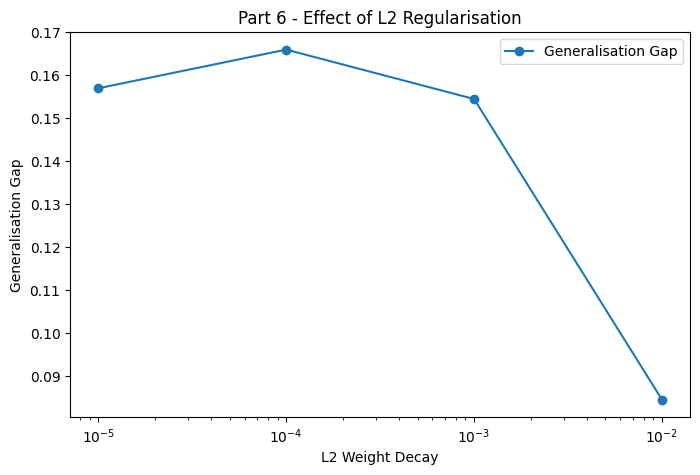

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(
    l2_values,
    [
        l2_results[x]["gap"]
        for x in l2_values
    ],
    marker="o",
    label="Generalisation Gap"
)

plt.xscale("log")

plt.xlabel("L2 Weight Decay")
plt.ylabel("Generalisation Gap")
plt.title(
    "Part 6 - Effect of L2 Regularisation"
)
plt.legend()

plt.show()

# Dropout gap plot


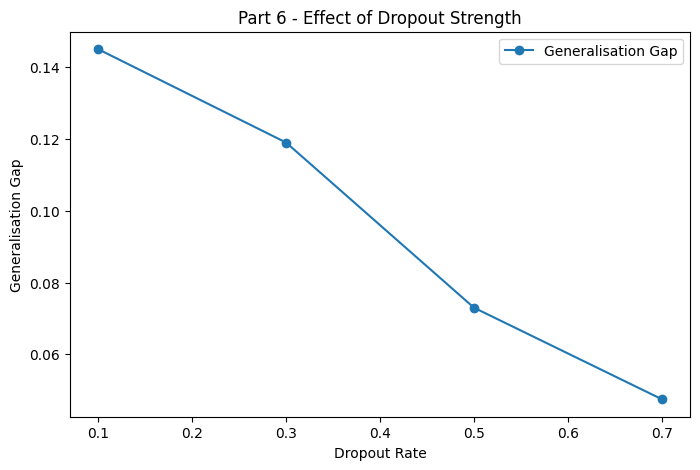

In [86]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_rates,
    [
        dropout_results[x]["gap"]
        for x in dropout_rates
    ],
    marker="o",
    label="Generalisation Gap"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Generalisation Gap")
plt.title(
    "Part 6 - Effect of Dropout Strength"
)
plt.legend()

plt.show()
 

# Conclusion
The unregularised model produced a generalisation gap of 0.154 percentage points. Among the tested methods, L2 weight decay with a setting of 0.0001 reduced the gap the most while preserving training accuracy, reducing the gap to 0.143 points with a training accuracy of 0.9715.
Stronger regularisation was not always better: increasing Dropout beyond 0.3 reduced training accuracy without a corresponding validation improvement, indicating over-regularisation. L1 increased the number of near-zero parameters, while dropout and L2 directly reduced overfitting. Batch normalisation mainly improved training stability, whereas early stopping prevented the network from continuing to fit the small training set after validation performance stopped improving. Increasing the amount of training data also produced a substantial improvement because it reduced the model's ability to memorise individual samples.


# **PART 7 — HYPERPARAMETER TUNING**


# Search space


In [87]:
search_space = {
    "learning_rate": [
        0.0003,
        0.0005,
        0.001,
        0.003
    ],

    "hidden_width": [
        128,
        256,
        512
    ],

    "dropout": [
        0.0,
        0.2,
        0.3,
        0.5
    ]
}

print(search_space)


{'learning_rate': [0.0003, 0.0005, 0.001, 0.003], 'hidden_width': [128, 256, 512], 'dropout': [0.0, 0.2, 0.3, 0.5]}


# Tunable model


In [88]:
class TunableMLP(nn.Module):

    def __init__(
        self,
        width,
        dropout
    ):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                784,
                width
            ),
            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                width,
                width
            ),
            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                width,
                10
            )
        )

    def forward(self, x):
        return self.net(x)


# Random configurations



In [90]:
rng = np.random.default_rng(SEED)

configurations = []

while len(configurations) < 12:

    config = {

        "learning_rate":
            float(
                rng.choice(
                    search_space[
                        "learning_rate"
                    ]
                )
            ),

        "hidden_width":
            int(
                rng.choice(
                    search_space[
                        "hidden_width"
                    ]
                )
            ),

        "dropout":
            float(
                rng.choice(
                    search_space[
                        "dropout"
                    ]
                )
            )
    }

    if config not in configurations:
        configurations.append(config)

configurations

[{'learning_rate': 0.0003, 'hidden_width': 512, 'dropout': 0.3},
 {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout': 0.5},
 {'learning_rate': 0.0003, 'hidden_width': 512, 'dropout': 0.0},
 {'learning_rate': 0.0003, 'hidden_width': 256, 'dropout': 0.5},
 {'learning_rate': 0.001, 'hidden_width': 512, 'dropout': 0.3},
 {'learning_rate': 0.003, 'hidden_width': 256, 'dropout': 0.0},
 {'learning_rate': 0.003, 'hidden_width': 256, 'dropout': 0.3},
 {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout': 0.5},
 {'learning_rate': 0.003, 'hidden_width': 256, 'dropout': 0.2},
 {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout': 0.0},
 {'learning_rate': 0.001, 'hidden_width': 512, 'dropout': 0.0},
 {'learning_rate': 0.003, 'hidden_width': 512, 'dropout': 0.2}]

# Cross-validation

In [92]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)
#Training function:
def train_cv_fold(
    X_fold_train,
    y_fold_train,
    X_fold_val,
    y_fold_val,
    config,
    epochs=10
):

    train_ds = TensorDataset(
        torch.tensor(
            X_fold_train,
            dtype=torch.float32
        ),
        torch.tensor(
            y_fold_train,
            dtype=torch.long
        )
    )

    val_ds = TensorDataset(
        torch.tensor(
            X_fold_val,
            dtype=torch.float32
        ),
        torch.tensor(
            y_fold_val,
            dtype=torch.long
        )
    )

    train_ld = DataLoader(
        train_ds,
        batch_size=128,
        shuffle=True
    )

    val_ld = DataLoader(
        val_ds,
        batch_size=256,
        shuffle=False
    )

    torch.manual_seed(SEED)

    model = TunableMLP(
        width=config[
            "hidden_width"
        ],
        dropout=config[
            "dropout"
        ]
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=config[
            "learning_rate"
        ]
    )

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_ld:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            loss.backward()
            optimizer.step()

    accuracy = classification_accuracy(
        model,
        val_ld
    )

    return accuracy


# Running all 12 configurations


In [93]:
cv_results = []

for config_number, config in enumerate(
    configurations,
    start=1
):

    print(
        f"\nConfiguration "
        f"{config_number}/12:",
        config
    )

    fold_scores = []

    for fold_number, (
        train_index,
        val_index
    ) in enumerate(
        skf.split(
            X_train,
            y_train
        ),
        start=1
    ):

        score = train_cv_fold(

            X_train[train_index],
            y_train[train_index],

            X_train[val_index],
            y_train[val_index],

            config
        )

        fold_scores.append(
            score
        )

        print(
            f"Fold {fold_number}: "
            f"{score:.4f}"
        )

    cv_results.append({

        **config,

        "mean_cv_accuracy":
            np.mean(
                fold_scores
            ),

        "std_cv_accuracy":
            np.std(
                fold_scores
            )
    })



Configuration 1/12: {'learning_rate': 0.0003, 'hidden_width': 512, 'dropout': 0.3}
Fold 1: 0.8413
Fold 2: 0.8612
Fold 3: 0.8394
Fold 4: 0.8325
Fold 5: 0.8612

Configuration 2/12: {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout': 0.5}
Fold 1: 0.8400
Fold 2: 0.8506
Fold 3: 0.8237
Fold 4: 0.8225
Fold 5: 0.8544

Configuration 3/12: {'learning_rate': 0.0003, 'hidden_width': 512, 'dropout': 0.0}
Fold 1: 0.8325
Fold 2: 0.8531
Fold 3: 0.8381
Fold 4: 0.8344
Fold 5: 0.8669

Configuration 4/12: {'learning_rate': 0.0003, 'hidden_width': 256, 'dropout': 0.5}
Fold 1: 0.8287
Fold 2: 0.8281
Fold 3: 0.8169
Fold 4: 0.8087
Fold 5: 0.8294

Configuration 5/12: {'learning_rate': 0.001, 'hidden_width': 512, 'dropout': 0.3}
Fold 1: 0.8356
Fold 2: 0.8712
Fold 3: 0.8413
Fold 4: 0.8500
Fold 5: 0.8688

Configuration 6/12: {'learning_rate': 0.003, 'hidden_width': 256, 'dropout': 0.0}
Fold 1: 0.8538
Fold 2: 0.8569
Fold 3: 0.8325
Fold 4: 0.8631
Fold 5: 0.8750

Configuration 7/12: {'learning_rate': 0.003, 'h

# Top five


In [94]:
cv_df = pd.DataFrame(
    cv_results
)

cv_df = cv_df.sort_values(
    "mean_cv_accuracy",
    ascending=False
).reset_index(drop=True)

top_five = cv_df.head(5)

top_five


,learning_rate,hidden_width,dropout,mean_cv_accuracy,std_cv_accuracy
0,0.001,512,0.0,0.856875,0.008633
1,0.003,256,0.0,0.856250,0.013925
2,0.001,512,0.3,0.853375,0.014348
3,0.003,256,0.2,0.853000,0.013650
4,0.003,512,0.2,0.852625,0.007780


# Selected configuration



In [95]:
best_config = (
    cv_df.iloc[0]
    .to_dict()
)

print(
    "Selected configuration:"
)

print(best_config)

Selected configuration:
{'learning_rate': 0.001, 'hidden_width': 512.0, 'dropout': 0.0, 'mean_cv_accuracy': 0.8568749999999999, 'std_cv_accuracy': 0.008633148324915999}


# Retraining data

In [99]:
best_l2 = max(
    l2_results.keys(),
    key=lambda x: l2_results[x]["val_acc"]
)

best_dropout = max(
    dropout_results.keys(),
    key=lambda x: dropout_results[x]["val_acc"]
)

print("Best L2:", best_l2)
print("Best dropout:", best_dropout)


Best L2: 0.0001
Best dropout: 0.5


# Full training loader

In [100]:
full_train_dataset = TensorDataset(

    torch.tensor(
        X_all,
        dtype=torch.float32
    ),

    torch.tensor(
        y_all,
        dtype=torch.long
    )
)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=128,
    shuffle=True
)


# Final model


In [102]:
final_model = TunableMLP(

    width=int(
        best_config[
            "hidden_width"
        ]
    ),

    dropout=float(
        best_config[
            "dropout"
        ]
    )

).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(

    final_model.parameters(),

    lr=float(
        best_config[
            "learning_rate"
        ]
    ),

    weight_decay=best_l2
)
#Train:
FINAL_EPOCHS = 20

for epoch in range(FINAL_EPOCHS):

    final_model.train()

    total_loss = 0

    for X_batch, y_batch in full_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = final_model(
            X_batch
        )

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item()
            * X_batch.size(0)
        )

    average_loss = (
        total_loss /
        len(full_train_loader.dataset)
    )

    print(
        f"Epoch {epoch+1}: "
        f"{average_loss:.4f}"
    )


Epoch 1: 0.8464
Epoch 2: 0.5092
Epoch 3: 0.4511
Epoch 4: 0.4068
Epoch 5: 0.3700
Epoch 6: 0.3593
Epoch 7: 0.3331
Epoch 8: 0.3137
Epoch 9: 0.3003
Epoch 10: 0.2848
Epoch 11: 0.2665
Epoch 12: 0.2522
Epoch 13: 0.2481
Epoch 14: 0.2341
Epoch 15: 0.2297
Epoch 16: 0.2196
Epoch 17: 0.2195
Epoch 18: 0.2017
Epoch 19: 0.2023
Epoch 20: 0.1797


# Using test dataset

In [103]:
test_dataset = TensorDataset(

    torch.tensor(
        X_test,
        dtype=torch.float32
    ),

    torch.tensor(
        y_test,
        dtype=torch.long
    )
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)


# Final predictions


In [104]:
final_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = final_model(
            X_batch
        )

        predictions = output.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            y_batch.numpy()
        )

all_predictions = np.array(
    all_predictions
)

all_targets = np.array(
    all_targets
)


# Required metrics


In [105]:
final_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

final_precision = precision_score(
    all_targets,
    all_predictions,
    average="macro"
)

final_recall = recall_score(
    all_targets,
    all_predictions,
    average="macro"
)

final_f1 = f1_score(
    all_targets,
    all_predictions,
    average="macro"
)

print(
    "Final Test Accuracy:",
    final_accuracy
)

print(
    "Macro Precision:",
    final_precision
)

print(
    "Macro Recall:",
    final_recall
)

print(
    "Macro F1:",
    final_f1
)


Final Test Accuracy: 0.8621833333333333
Macro Precision: 0.8708921905954343
Macro Recall: 0.8621833333333333
Macro F1: 0.8631779180497021


# Confusion matrix


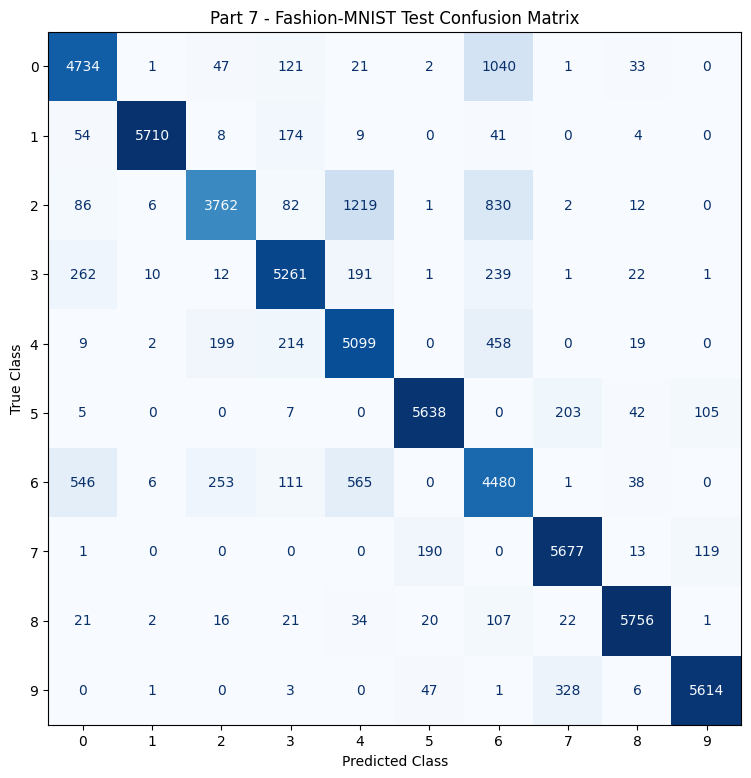

In [106]:
cm = confusion_matrix(
    all_targets,
    all_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(
    figsize=(9, 9)
)

display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Part 7 - Fashion-MNIST Test Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()


# Improvement over Part 2 baseline


In [107]:
part2_relu_model = (
    activation_results[
        "relu"
    ]["model"]
)

baseline_test_accuracy = (
    classification_accuracy(
        part2_relu_model,
        test_loader
    )
)

improvement_pp = (
    final_accuracy
    - baseline_test_accuracy
) * 100

print(
    "Part 2 baseline test accuracy:",
    baseline_test_accuracy
)

print(
    "Final model test accuracy:",
    final_accuracy
)

print(
    "Improvement:",
    improvement_pp,
    "percentage points"
)


Part 2 baseline test accuracy: 0.8513666666666667
Final model test accuracy: 0.8621833333333333
Improvement: 1.0816666666666586 percentage points


# Conclusion
The final tuned model achieved a test accuracy of 86.22%, compared with 85.14% for the Part 2 ReLU baseline. This corresponds to an improvement of 1.08 percentage points.